In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_semantic_data.csv")

In [3]:
df.head()

,label,response_embeddings,document_embeddings,question_embeddings,doc_response_similarity,question_response_similarity,question_document_similarity
0,GROUNDED,[ 9.64630209e-03 3.33776027e-02 1.66789331e-...,[-2.88786087e-02 2.87237838e-02 7.56983936e-...,[-3.22162621e-02 2.47374829e-02 -1.71899684e-...,0.782924,0.901967,0.729742
1,GROUNDED,[-3.62419002e-02 -3.03612615e-04 -2.93646846e-...,[-5.43885157e-02 -7.26703554e-03 -8.73105507e-...,[-2.26425249e-02 -4.85397736e-03 -6.18805736e-...,0.211373,0.701803,0.096944
2,PARTIALLY_GROUNDED,[ 8.70998949e-02 8.42432529e-02 -2.45561693e-...,[-6.24402775e-04 1.15105011e-01 -6.74891472e-...,[-2.41323262e-02 5.54744676e-02 -3.50597836e-...,0.825851,0.716620,0.649443
3,GROUNDED,[-4.43644524e-02 -5.05170338e-02 -1.04717642e-...,[-3.21069025e-02 -8.86590183e-02 -1.38417780e-...,[-2.07818262e-02 4.40060645e-02 -1.34034619e-...,0.583459,0.641136,0.506321
4,GROUNDED,[ 3.64738293e-02 -7.47442544e-02 2.30430868e-...,[ 2.12941747e-02 -1.13025522e-02 2.27199793e-...,[ 3.45350206e-02 -3.44853997e-02 2.92823091e-...,0.306352,0.847259,0.340603


In [4]:
df.columns

Index(['label', 'response_embeddings', 'document_embeddings',
       'question_embeddings', 'doc_response_similarity',
       'question_response_similarity', 'question_document_similarity'],
      dtype='str')

In [12]:
df.isnull().sum()

label                           375
response_embeddings               0
document_embeddings               0
question_embeddings               0
doc_response_similarity           0
question_response_similarity      0
question_document_similarity      0
dtype: int64

In [24]:
valid_labels = ["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
bad_rows = df[~df["label"].isin(valid_labels)]
print(len(bad_rows))
bad_rows.head(10)

df = df[df["label"].isin(valid_labels)].reset_index(drop=True)
print(df["label"].value_counts())

34
label
GROUNDED              47265
HALLUCINATED          40397
PARTIALLY_GROUNDED     7515
Name: count, dtype: int64


In [25]:
X=df.drop(["label"],axis=1)
y=df["label"]

In [26]:
import numpy as np

X_embedding = df[["question_embeddings", "document_embeddings", "response_embeddings"]].map(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)

In [27]:
X=pd.concat([X_embedding,X[["question_response_similarity","question_document_similarity","doc_response_similarity"]]],axis=1)

In [28]:
X.isna().sum()

question_embeddings             0
document_embeddings             0
response_embeddings             0
question_response_similarity    0
question_document_similarity    0
doc_response_similarity         0
dtype: int64

In [29]:
y.isna().sum()

np.int64(0)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y)

In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
X_train = np.hstack([
    np.vstack(X_train["question_embeddings"]),
    np.vstack(X_train["document_embeddings"]),
    np.vstack(X_train["response_embeddings"])
])

X_test = np.hstack([
    np.vstack(X_test["question_embeddings"]),
    np.vstack(X_test["document_embeddings"]),
    np.vstack(X_test["response_embeddings"])
])

print(X_train.shape)

(76141, 1152)


In [33]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Us

In [34]:
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_smote).value_counts())

Before:
label
GROUNDED              37812
HALLUCINATED          32317
PARTIALLY_GROUNDED     6012
Name: count, dtype: int64

After:
label
GROUNDED              37812
HALLUCINATED          37812
PARTIALLY_GROUNDED    37812
Name: count, dtype: int64


In [35]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

Accuracy: 0.6551271275478041
Macro F1: 0.5893691297000888
                    precision    recall  f1-score   support

          GROUNDED       0.76      0.63      0.69      9453
      HALLUCINATED       0.81      0.68      0.74      8080
PARTIALLY_GROUNDED       0.23      0.66      0.34      1503

          accuracy                           0.66     19036
         macro avg       0.60      0.66      0.59     19036
      weighted avg       0.74      0.66      0.68     19036



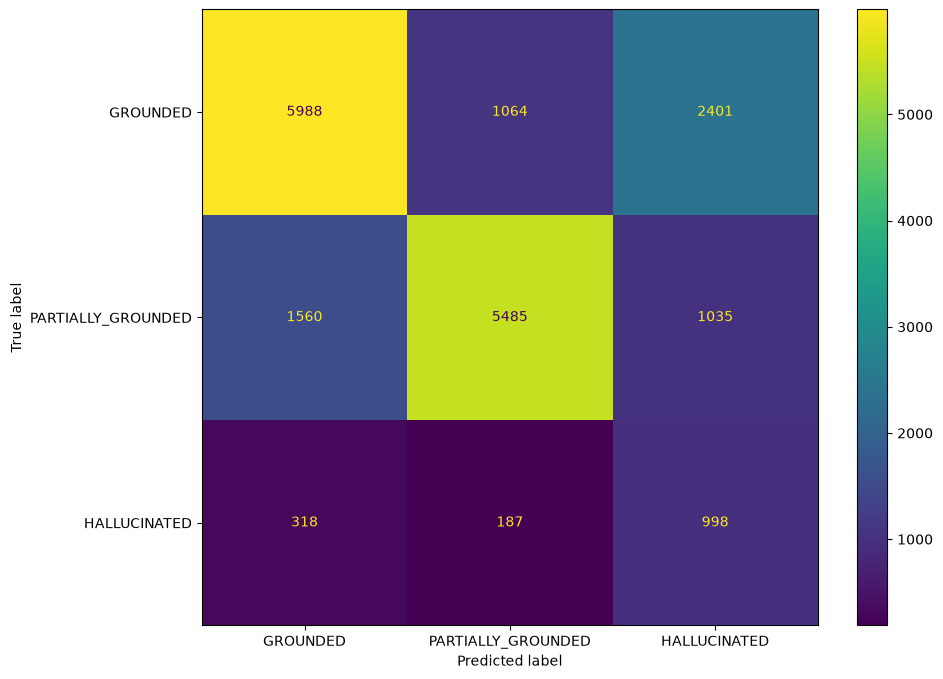

In [36]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

In [37]:
from sklearn.svm import LinearSVC

Accuracy: 0.6595923513343139
Macro F1: 0.5953298759855836
                    precision    recall  f1-score   support

          GROUNDED       0.76      0.64      0.70      9453
      HALLUCINATED       0.83      0.68      0.75      8080
PARTIALLY_GROUNDED       0.23      0.69      0.34      1503

          accuracy                           0.66     19036
         macro avg       0.61      0.67      0.60     19036
      weighted avg       0.75      0.66      0.69     19036



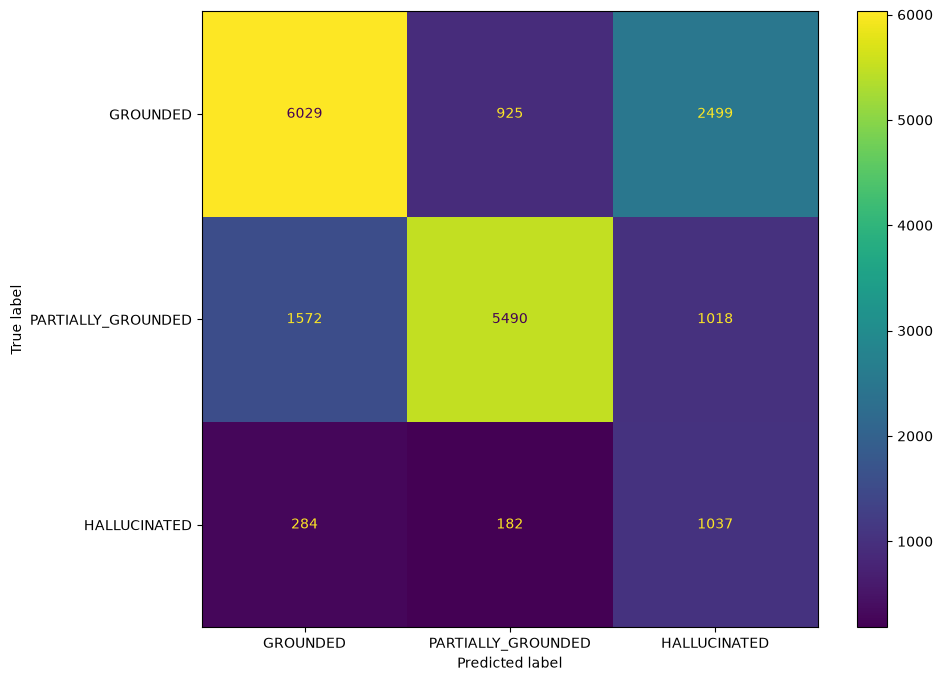

In [38]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

Accuracy: 0.8183441899558731
Macro F1: 0.6740426185999101
                    precision    recall  f1-score   support

          GROUNDED       0.86      0.84      0.85      9453
      HALLUCINATED       0.88      0.89      0.88      8080
PARTIALLY_GROUNDED       0.28      0.30      0.29      1503

          accuracy                           0.82     19036
         macro avg       0.67      0.68      0.67     19036
      weighted avg       0.82      0.82      0.82     19036



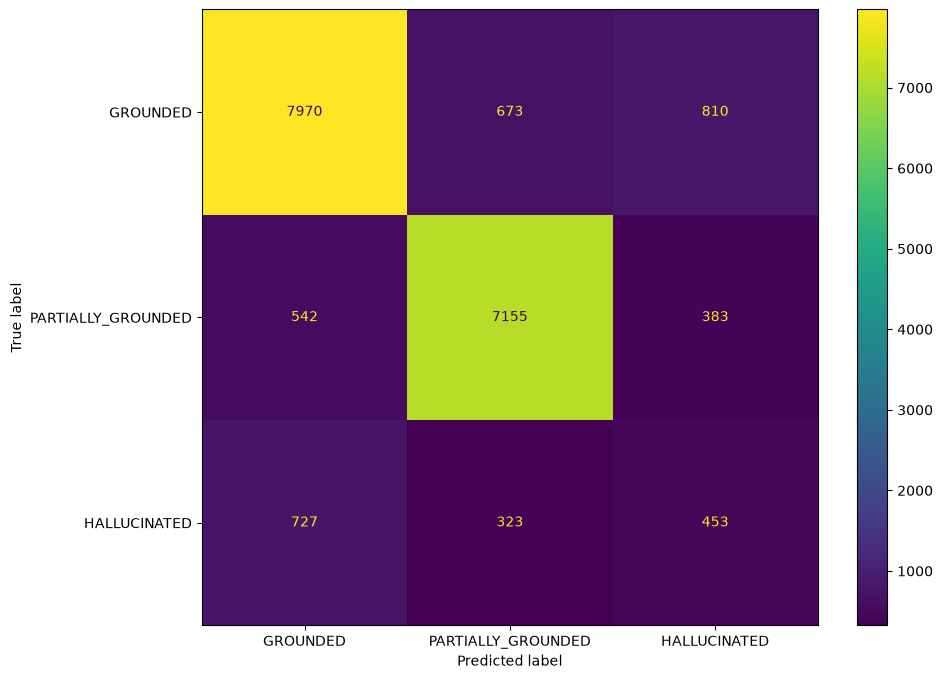

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        rf_pred,
        average="macro"
    )
)

print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()


In [40]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y)

In [42]:
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [43]:
X_train = np.hstack([
    np.vstack(X_train["question_embeddings"]),
    np.vstack(X_train["document_embeddings"]),
    np.vstack(X_train["response_embeddings"])
])

X_test = np.hstack([
    np.vstack(X_test["question_embeddings"]),
    np.vstack(X_test["document_embeddings"]),
    np.vstack(X_test["response_embeddings"])
])

print(X_train.shape)

(76141, 1152)


In [44]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train_encoded
)

Accuracy: 0.7450619878125657
Macro F1: 0.6529760664224952
              precision    recall  f1-score   support

           0       0.83      0.74      0.79      9453
           1       0.89      0.78      0.83      8080
           2       0.24      0.57      0.34      1503

    accuracy                           0.75     19036
   macro avg       0.66      0.70      0.65     19036
weighted avg       0.81      0.75      0.77     19036



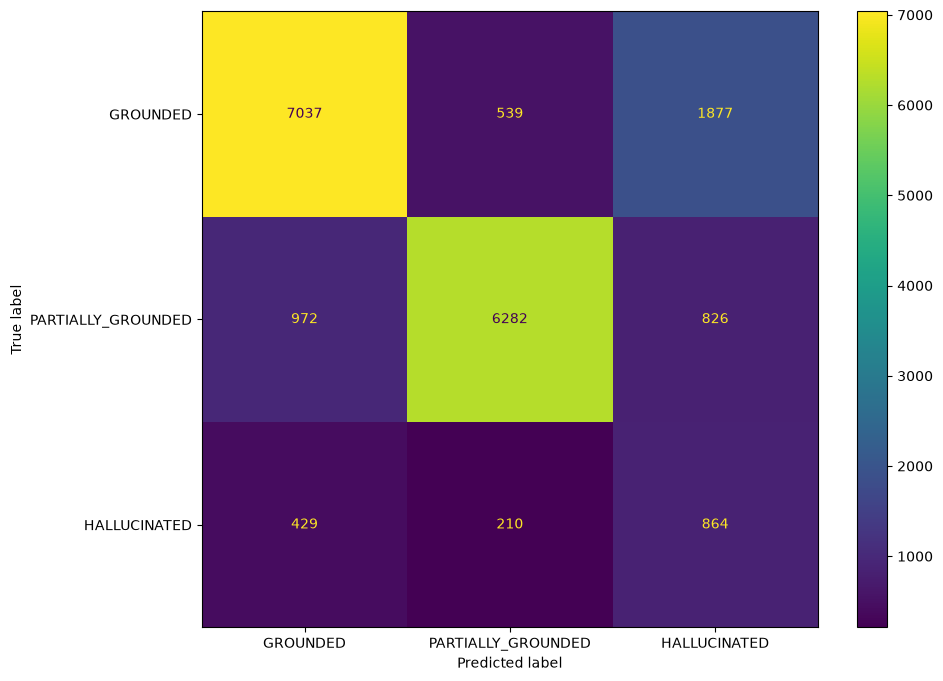

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test_encoded, xgb_pred))

print(
    "Macro F1:",
    f1_score(
        y_test_encoded,
        xgb_pred,
        average="macro"
    )
)

print(classification_report(y_test_encoded, xgb_pred))

cm = confusion_matrix(y_test_encoded, xgb_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()